# Modularidad

# Actividad

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

SEED = 863

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
# cargar la red real
folder = Path("data/dataverse/gexf")
movie_id = 774
fp = folder / f"{movie_id}.gexf"

G_real = nx.read_gexf(fp, node_type=int)

## 1. Actividad


In [3]:
from networkx.algorithms.community import greedy_modularity_communities, louvain_communities


def get_display_labels(G):
    raw = nx.get_node_attributes(G, "label")
    return {node: raw.get(node, str(node)) for node in G.nodes()}


def communities_to_lookup(communities):
    lookup = {}
    for idx, community in enumerate(communities):
        for node in community:
            lookup[node] = idx
    return lookup


def sort_nodes_in_group(G, group, labels):
    return sorted(group, key=lambda node: (-G.degree(node), labels[node]))


def partition_summary(G, communities, labels):
    bet = nx.betweenness_centrality(G)
    rows = []
    for idx, community in enumerate(sorted(communities, key=len, reverse=True)):
        sub = G.subgraph(community)
        ranked_degree = sort_nodes_in_group(G, community, labels)
        ranked_bet = sorted(
            community,
            key=lambda node: (-bet[node], labels[node]),
        )
        rows.append(
            {
                "comunidad": idx,
                "tamano": len(community),
                "aristas_internas": sub.number_of_edges(),
                "densidad_interna": round(nx.density(sub), 4),
                "lideres_por_grado": ", ".join(labels[node] for node in ranked_degree[:6]),
                "lideres_por_intermediacion": ", ".join(labels[node] for node in ranked_bet[:4]),
                "miembros": ", ".join(labels[node] for node in ranked_degree),
            }
        )
    return pd.DataFrame(rows)


def bridge_edges_table(G, communities, labels, top_n=12):
    lookup = communities_to_lookup(communities)
    rows = []
    for u, v, data in G.edges(data=True):
        cu = lookup[u]
        cv = lookup[v]
        if cu == cv:
            continue
        rows.append(
            {
                "peso": data.get("weight", 1.0),
                "origen": labels[u],
                "comunidad_origen": cu,
                "destino": labels[v],
                "comunidad_destino": cv,
            }
        )
    if not rows:
        return pd.DataFrame(columns=["peso", "origen", "comunidad_origen", "destino", "comunidad_destino"])
    return pd.DataFrame(rows).sort_values(
        ["peso", "origen", "destino"],
        ascending=[False, True, True],
    ).head(top_n)


def draw_partition(ax, G, communities, labels, title, pos=None):
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    lookup = communities_to_lookup(communities)
    node_colors = np.array([lookup[node] for node in G.nodes()])
    node_sizes = np.array([220 + 18 * G.degree(node) for node in G.nodes()])
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        alpha=0.25,
        width=1.0,
        edge_color="#94a3b8",
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        cmap="nipy_spectral",
        linewidths=0.6,
        edgecolors="white",
    )
    font_size = 9 if G.number_of_nodes() <= 25 else 7
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=font_size)
    ax.set_title(title)
    ax.axis("off")
    return pos


def full_modularity_matrix(G, nodelist=None):
    if nodelist is None:
        nodelist = list(G.nodes())
    m = G.number_of_edges()
    degrees = dict(G.degree())
    B = np.zeros((len(nodelist), len(nodelist)), dtype=float)
    for i, u in enumerate(nodelist):
        for j, v in enumerate(nodelist):
            adjacency = 1.0 if G.has_edge(u, v) else 0.0
            B[i, j] = adjacency - degrees[u] * degrees[v] / (2 * m)
    return B


def modularity_spectrum(G, labels):
    nodelist = list(G.nodes())
    B = full_modularity_matrix(G, nodelist=nodelist)
    eigvals, eigvecs = np.linalg.eigh(B)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    matrix_df = pd.DataFrame(
        B,
        index=[labels[node] for node in nodelist],
        columns=[labels[node] for node in nodelist],
    )
    eigen_df = pd.DataFrame(
        {
            "indice": np.arange(1, len(eigvals) + 1),
            "eigenvalor": eigvals,
        }
    )
    leading_df = pd.DataFrame(
        {
            "nodo": [labels[node] for node in nodelist],
            "componente_eigenvector_principal": eigvecs[:, 0],
            "signo": np.where(eigvecs[:, 0] >= 0, "+", "-"),
        }
    ).sort_values("componente_eigenvector_principal")
    return matrix_df, eigen_df, leading_df


def generalized_modularity_matrix(G, community):
    nodelist = list(community)
    B = full_modularity_matrix(G, nodelist=nodelist)
    row_sums = B.sum(axis=1)
    Bg = B.copy()
    diag = np.arange(len(nodelist))
    Bg[diag, diag] -= row_sums
    return Bg, nodelist


def leading_split_generalized(G, community, labels):
    Bg, nodelist = generalized_modularity_matrix(G, community)
    eigvals, eigvecs = np.linalg.eigh(Bg)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    leading_eval = float(eigvals[0])
    leading_vec = eigvecs[:, 0]
    signs = np.where(leading_vec >= 0, 1, -1)
    if np.all(signs == 1) or np.all(signs == -1):
        order_vec = np.argsort(leading_vec)
        half = len(nodelist) // 2
        signs = np.ones(len(nodelist), dtype=int)
        signs[order_vec[:half]] = -1
    group_pos = {nodelist[i] for i, sign in enumerate(signs) if sign > 0}
    group_neg = set(nodelist) - group_pos
    delta_q = float((signs @ Bg @ signs) / (4 * G.number_of_edges()))
    vector_df = pd.DataFrame(
        {
            "nodo": [labels[node] for node in nodelist],
            "componente": leading_vec,
            "signo": np.where(signs > 0, "+", "-"),
        }
    ).sort_values("componente")
    return {
        "grupo_positivo": group_pos,
        "grupo_negativo": group_neg,
        "leading_eigenvalue": leading_eval,
        "delta_q": delta_q,
        "eigenvalues": eigvals,
        "leading_vector_df": vector_df,
    }


def recursive_spectral_partition(G, target_count, labels):
    partition = [set(G.nodes())]
    trace_rows = []
    first_split = None
    while len(partition) < target_count:
        candidates = []
        for idx, community in enumerate(partition):
            if len(community) < 2:
                continue
            split = leading_split_generalized(G, community, labels)
            candidate_partition = (
                partition[:idx]
                + [split["grupo_positivo"], split["grupo_negativo"]]
                + partition[idx + 1 :]
            )
            candidates.append(
                {
                    "idx": idx,
                    "split": split,
                    "candidate_partition": candidate_partition,
                    "candidate_modularity": nx.algorithms.community.modularity(G, candidate_partition),
                }
            )
        best = max(
            candidates,
            key=lambda item: (
                item["split"]["delta_q"],
                item["split"]["leading_eigenvalue"],
            ),
        )
        split = best["split"]
        if first_split is None:
            first_split = split
        trace_rows.append(
            {
                "paso": len(trace_rows) + 1,
                "grupo_bisecado": best["idx"],
                "tamano_original": len(partition[best["idx"]]),
                "tamano_grupo_positivo": len(split["grupo_positivo"]),
                "tamano_grupo_negativo": len(split["grupo_negativo"]),
                "leading_eigenvalue": split["leading_eigenvalue"],
                "delta_q": split["delta_q"],
                "modularidad_acumulada": best["candidate_modularity"],
            }
        )
        partition = best["candidate_partition"]
    partition = sorted(partition, key=len, reverse=True)
    trace_df = pd.DataFrame(trace_rows)
    return partition, trace_df, first_split


def comparison_table(G, greedy_partition, spectral_partition):
    rows = [
        {
            "metodo": "greedy_modularity_communities",
            "comunidades": len(greedy_partition),
            "modularidad": nx.algorithms.community.modularity(G, greedy_partition),
        },
        {
            "metodo": "biseccion espectral",
            "comunidades": len(spectral_partition),
            "modularidad": nx.algorithms.community.modularity(G, spectral_partition),
        },
    ]
    try:
        louvain_partition = sorted(list(louvain_communities(G, seed=SEED)), key=len, reverse=True)
        rows.append(
            {
                "metodo": "louvain_communities",
                "comunidades": len(louvain_partition),
                "modularidad": nx.algorithms.community.modularity(G, louvain_partition),
            }
        )
    except Exception:
        pass
    return pd.DataFrame(rows).sort_values("modularidad", ascending=False).reset_index(drop=True)


def plot_modularity_heatmap(ax, matrix_df, title):
    values = matrix_df.to_numpy()
    vmax = np.abs(values).max()
    image = ax.imshow(values, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    step = max(1, len(matrix_df) // 12)
    ticks = np.arange(0, len(matrix_df), step)
    ax.set_xticks(ticks)
    ax.set_xticklabels(matrix_df.columns[::step], rotation=90, fontsize=8)
    ax.set_yticks(ticks)
    ax.set_yticklabels(matrix_df.index[::step], fontsize=8)
    ax.set_title(title)
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


In [4]:
labels = get_display_labels(G_real)
pos_sw = nx.kamada_kawai_layout(G_real)

resumen_red = pd.DataFrame(
    [
        {
            "nodos": G_real.number_of_nodes(),
            "aristas": G_real.number_of_edges(),
            "densidad": nx.density(G_real),
            "grado_medio": np.mean([grado for _, grado in G_real.degree()]),
            "es_conexa": nx.is_connected(G_real),
        }
    ]
).round(4)

display(resumen_red)


,nodos,aristas,densidad,grado_medio,es_conexa
0,47,148,0.1369,6.2979,True


## 2. Comunidades 

Con `greedy_modularity_communities` aparecen **4 comunidades** y la modularidad queda en **0.3453**, que ya es un valor alto. En esta red los grupos corresponden a bloques de escenas y subtramas.


In [5]:
comunidades_greedy = sorted(list(greedy_modularity_communities(G_real)), key=len, reverse=True)
modularidad_greedy = nx.algorithms.community.modularity(G_real, comunidades_greedy)
resumen_greedy = partition_summary(G_real, comunidades_greedy, labels)
aristas_puente_greedy = bridge_edges_table(G_real, comunidades_greedy, labels, top_n=15)

print(f"Comunidades detectadas: {len(comunidades_greedy)}")
print(f"Modularidad greedy: {modularidad_greedy:.4f}")
display(resumen_greedy)
display(aristas_puente_greedy)


Comunidades detectadas: 4
Modularidad greedy: 0.3453


,comunidad,tamano,aristas_internas,densidad_interna,lideres_por_grado,lideres_por_intermediacion,miembros
0,0,16,36,0.3000,"PADMÉ, ANAKIN, CAPTAIN TYPHO, BERU, OWEN, CLIEGG","PADMÉ, ANAKIN, CAPTAIN TYPHO, BERU","PADMÉ, ANAKIN, CAPTAIN TYPHO, BERU, OWEN, CLIE..."
1,1,13,20,0.2564,"OBI-WAN, JANGO FETT, TAUN WE, BOBA FETT, JANGO...","OBI-WAN, JANGO FETT, TAUN WE, BOBA FETT","OBI-WAN, JANGO FETT, TAUN WE, BOBA FETT, JANGO..."
2,2,13,38,0.4872,"YODA, MACE WINDU, JAR JAR, PALPATINE, MAS AMED...","YODA, MACE WINDU, PALPATINE, JAR JAR","YODA, MACE WINDU, JAR JAR, PALPATINE, MAS AMED..."
3,3,5,7,0.7000,"COUNT DOOKU, NUTE GUNRAY, POGGLE, SUN RIT, DAR...","COUNT DOOKU, DARTH SIDIOUS, NUTE GUNRAY, POGGLE","COUNT DOOKU, NUTE GUNRAY, POGGLE, SUN RIT, DAR..."


,peso,origen,comunidad_origen,destino,comunidad_destino
10,13.0,ANAKIN,0,OBI-WAN,1
39,5.0,OBI-WAN,1,YODA,2
40,4.0,OBI-WAN,1,PADMÉ,0
8,3.0,ANAKIN,0,JAR JAR,2
19,3.0,COUNT DOOKU,3,PADMÉ,0
29,3.0,MACE WINDU,2,OBI-WAN,1
28,3.0,MACE WINDU,2,PADMÉ,0
17,2.0,COUNT DOOKU,3,MACE WINDU,2
20,2.0,COUNT DOOKU,3,YODA,2
24,2.0,JAR JAR,2,OBI-WAN,1


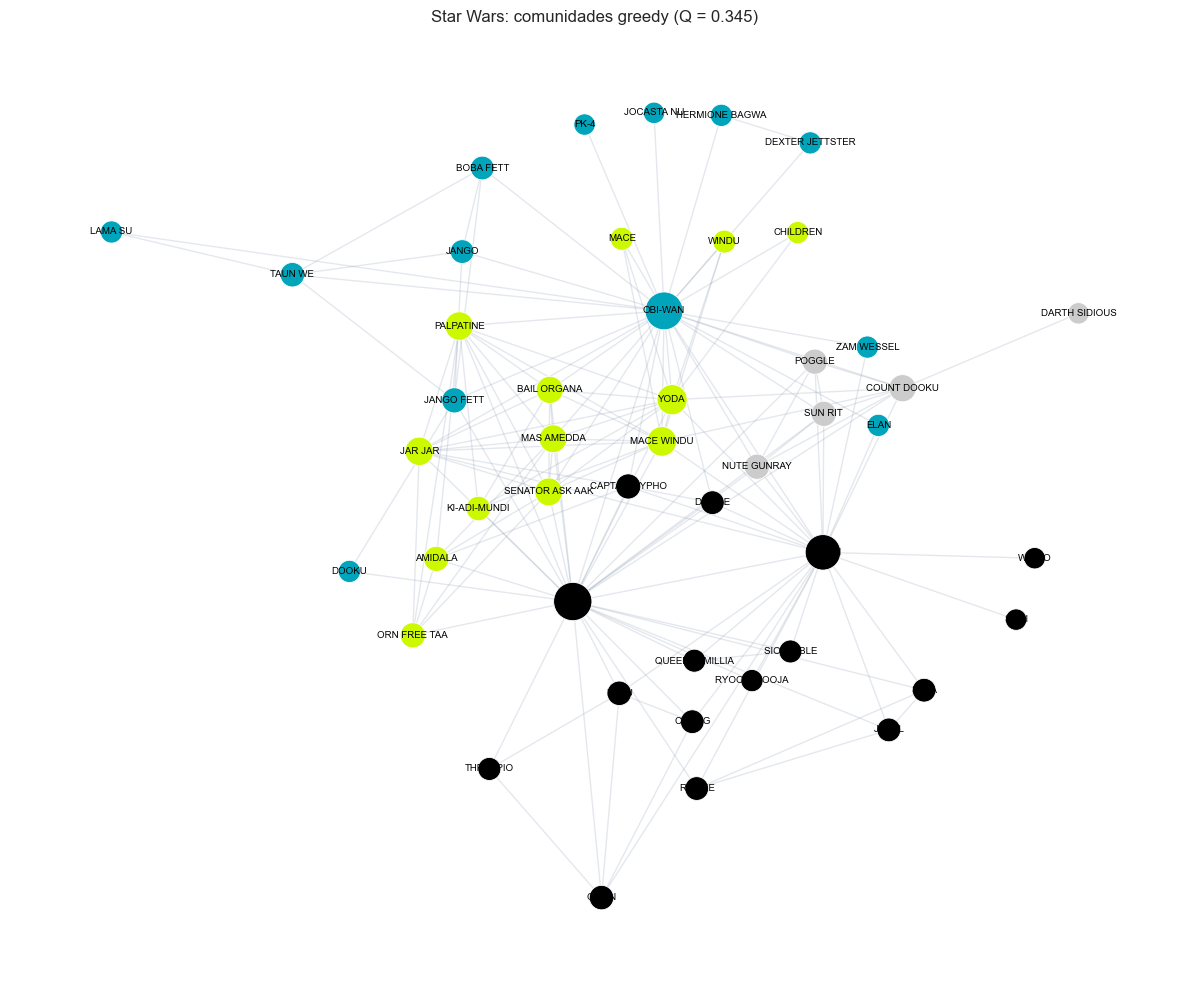

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
draw_partition(
    ax,
    G_real,
    comunidades_greedy,
    labels,
    title=f"Star Wars: comunidades greedy (Q = {modularidad_greedy:.3f})",
    pos=pos_sw,
)
plt.tight_layout()
plt.show()


**¿Qué tipo de comunidades se detectan?**

Aquí los grupos sí están muy pegados a la historia de la película:

- Un bloque de **Padmé-Anakin-Naboo-Tatooine** con `PADMÉ`, `ANAKIN`, `CAPTAIN TYPHO`, `BERU`, `OWEN`, `CLIEGG`, `SHMI`, `WATTO`, `DORME`, `JOBAL`, `RUWEE`, `SOLA`, `QUEEN JAMILLIA`, `SIO BIBBLE`, `THREEPIO` y `RYOO & POOJA`.
- Un bloque de **investigación y Kamino** con `OBI-WAN`, `JANGO FETT`, `TAUN WE`, `BOBA FETT`, `DEXTER JETTSTER`, `LAMA SU`, `ZAM WESSEL`, `JOCASTA NU`, `PK-4` y las variantes `JANGO` y `DOOKU` que trae el dataset.
- Un bloque de **Senado y Consejo Jedi** con `YODA`, `MACE WINDU`, `JAR JAR`, `PALPATINE`, `MAS AMEDDA`, `SENATOR ASK AAK`, `BAIL ORGANA`, `ORN FREE TAA`, `KI-ADI-MUNDI`, `AMIDALA`, `CHILDREN` y las variantes `MACE` y `WINDU`.
- Un bloque pequeño pero muy denso de **dirigencia separatista** con `COUNT DOOKU`, `NUTE GUNRAY`, `POGGLE`, `SUN RIT` y `DARTH SIDIOUS`.

**Factores importantes para que los nodos queden en esas comunidades**

- Coaparecer repetidamente en el mismo espacio narrativo: Naboo, Tatooine, Kamino, Coruscant o Geonosis.
- Compartir personajes importantes. En esta red `PADMÉ`, `OBI-WAN`, `ANAKIN` y `COUNT DOOKU` cosen subtramas distintas.
- Mantener pocos enlaces fuertes hacia fuera del grupo. Las aristas-puente más intensas son `ANAKIN-OBI-WAN`, `OBI-WAN-YODA`, `OBI-WAN-PADMÉ` y `MACE WINDU-PADMÉ`, así que justo esos personajes son quienes impiden que la red se parta por completo.


## 2.1 Partición de Gephi con `Modularity Class`

Se obtienen los mismos resultados.

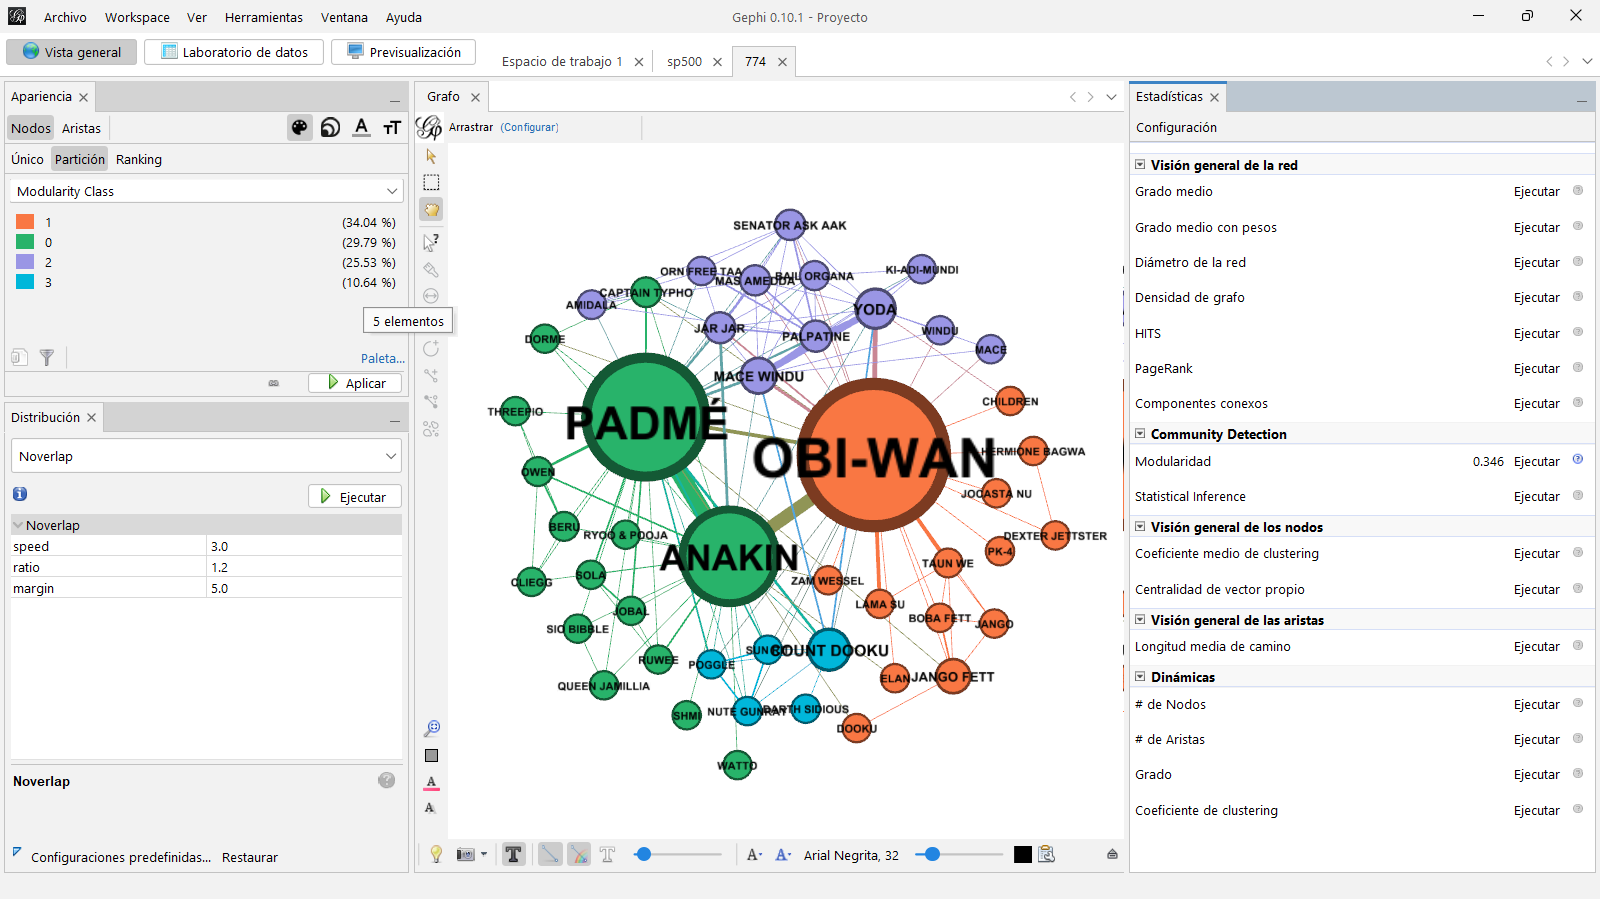

## 3. Matriz de modularidad, eigenvalores y eigenvectores

Repito el análisis con la matriz de modularidad y la regla espectral de bisecar por el signo del eigenvector principal. Luego aplico la bisección recursiva hasta llegar a las mismas **4 comunidades** detectadas antes.


In [8]:
B_df_sw, eigen_df_sw, leading_df_sw = modularity_spectrum(G_real, labels)
comunidades_spectral, trace_sw, first_split_sw = recursive_spectral_partition(
    G_real,
    target_count=len(comunidades_greedy),
    labels=labels,
)
modularidad_spectral = nx.algorithms.community.modularity(G_real, comunidades_spectral)
resumen_spectral = partition_summary(G_real, comunidades_spectral, labels)
comparacion_sw = comparison_table(G_real, comunidades_greedy, comunidades_spectral)

display(comparacion_sw.round(4))
display(eigen_df_sw.head(10).round(4))
display(leading_df_sw.round(4))
display(trace_sw.round(4))
display(resumen_spectral)
display(B_df_sw.iloc[:12, :12].round(2))


,metodo,comunidades,modularidad
0,greedy_modularity_communities,4,0.3453
1,louvain_communities,4,0.3350
2,biseccion espectral,4,0.2980


,indice,eigenvalor
0,1,5.6516
1,2,4.5197
2,3,3.3622
3,4,2.4843
4,5,2.3076
5,6,2.1018
6,7,1.4302
7,8,1.1526
8,9,1.0426
9,10,0.7338


,nodo,componente_eigenvector_principal,signo
1,ANAKIN,-0.3251,-
25,NUTE GUNRAY,-0.1571,-
32,POGGLE,-0.1571,-
40,SUN RIT,-0.1571,-
3,BERU,-0.1510,-
28,OWEN,-0.1510,-
7,CLIEGG,-0.1367,-
18,JOBAL,-0.1288,-
34,RUWEE,-0.1288,-
39,SOLA,-0.1288,-


,paso,grupo_bisecado,tamano_original,tamano_grupo_positivo,tamano_grupo_negativo,leading_eigenvalue,delta_q,modularidad_acumulada
0,1,0,47,31,16,5.6516,0.2658,0.2179
1,2,0,31,8,23,2.2506,0.0697,0.2817
2,3,1,23,5,18,0.7908,0.0143,0.2980


,comunidad,tamano,aristas_internas,densidad_interna,lideres_por_grado,lideres_por_intermediacion,miembros
0,0,18,38,0.2484,"PADMÉ, ANAKIN, CAPTAIN TYPHO, BERU, OWEN, CLIEGG","PADMÉ, ANAKIN, CAPTAIN TYPHO, BERU","PADMÉ, ANAKIN, CAPTAIN TYPHO, BERU, OWEN, CLIE..."
1,1,16,50,0.4167,"OBI-WAN, YODA, MACE WINDU, JAR JAR, PALPATINE,...","OBI-WAN, YODA, MACE WINDU, PALPATINE","OBI-WAN, YODA, MACE WINDU, JAR JAR, PALPATINE,..."
2,2,8,9,0.3214,"JANGO FETT, TAUN WE, BOBA FETT, JANGO, DEXTER ...","JANGO FETT, TAUN WE, BOBA FETT, DEXTER JETTSTER","JANGO FETT, TAUN WE, BOBA FETT, JANGO, DEXTER ..."
3,3,5,7,0.7000,"COUNT DOOKU, NUTE GUNRAY, POGGLE, SUN RIT, DAR...","COUNT DOOKU, DARTH SIDIOUS, NUTE GUNRAY, POGGLE","COUNT DOOKU, NUTE GUNRAY, POGGLE, SUN RIT, DAR..."


,AMIDALA,ANAKIN,BAIL ORGANA,BERU,BOBA FETT,CAPTAIN TYPHO,CHILDREN,CLIEGG,COUNT DOOKU,DARTH SIDIOUS,DEXTER JETTSTER,DOOKU
AMIDALA,-0.12,-0.49,-0.18,-0.10,-0.08,0.88,-0.04,-0.08,-0.18,-0.02,-0.04,-0.04
ANAKIN,-0.49,-1.95,-0.73,0.59,-0.32,0.51,-0.16,0.68,0.27,-0.08,-0.16,-0.16
BAIL ORGANA,-0.18,-0.73,-0.27,-0.15,-0.12,-0.18,-0.06,-0.12,-0.27,-0.03,-0.06,-0.06
BERU,-0.10,0.59,-0.15,-0.08,-0.07,-0.10,-0.03,0.93,-0.15,-0.02,-0.03,-0.03
BOBA FETT,-0.08,-0.32,-0.12,-0.07,-0.05,-0.08,-0.03,-0.05,-0.12,-0.01,-0.03,-0.03
CAPTAIN TYPHO,0.88,0.51,-0.18,-0.10,-0.08,-0.12,-0.04,-0.08,-0.18,-0.02,-0.04,-0.04
CHILDREN,-0.04,-0.16,-0.06,-0.03,-0.03,-0.04,-0.01,-0.03,-0.06,-0.01,-0.01,-0.01
CLIEGG,-0.08,0.68,-0.12,0.93,-0.05,-0.08,-0.03,-0.05,-0.12,-0.01,-0.03,-0.03
COUNT DOOKU,-0.18,0.27,-0.27,-0.15,-0.12,-0.18,-0.06,-0.12,-0.27,0.97,-0.06,-0.06
DARTH SIDIOUS,-0.02,-0.08,-0.03,-0.02,-0.01,-0.02,-0.01,-0.01,0.97,-0.00,-0.01,-0.01


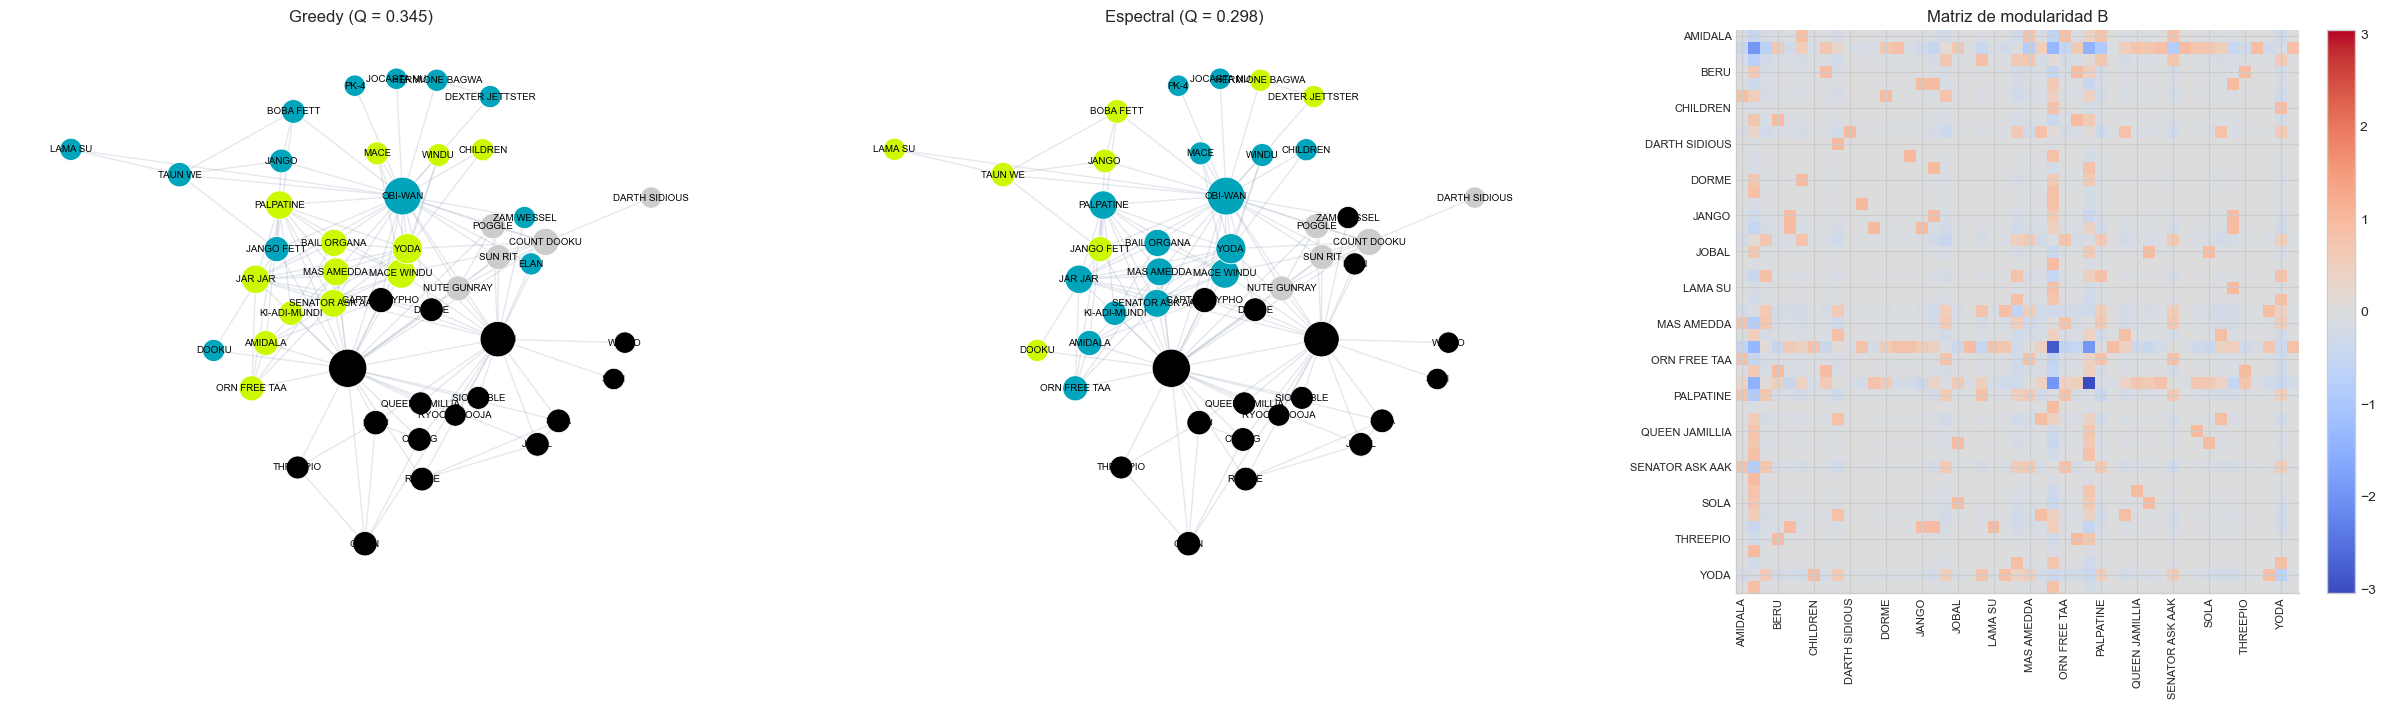

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

draw_partition(
    axes[0],
    G_real,
    comunidades_greedy,
    labels,
    title=f"Greedy (Q = {modularidad_greedy:.3f})",
    pos=pos_sw,
)
draw_partition(
    axes[1],
    G_real,
    comunidades_spectral,
    labels,
    title=f"Espectral (Q = {modularidad_spectral:.3f})",
    pos=pos_sw,
)
plot_modularity_heatmap(axes[2], B_df_sw, "Matriz de modularidad B")

plt.tight_layout()
plt.show()


**¿Qué cambia con la bisección espectral?**

La partición espectral también llega a **4 comunidades**, pero la modularidad baja a cerca de **0.2980**, así que la separación es más meror que con `greedy`.

Lo que más llama la atención es esto:

- El **primer eigenvector** ya divide la película en dos polos grandes: por un lado el bloque institucional de `OBI-WAN`, `YODA`, `MACE WINDU`, `PALPATINE`, `BAIL ORGANA` y el Senado; por el otro, el frente `PADMÉ-ANAKIN` junto con Tatooine, la persecución inicial y varios siths.
- En los cortes siguientes se desprende una célula más pura de **Kamino/Jango** y se mantiene casi intacto el grupo separatista de `COUNT DOOKU`, `NUTE GUNRAY`, `POGGLE`, `SUN RIT` y `DARTH SIDIOUS`.
- La diferencia más fuerte respecto al inciso anterior es que `OBI-WAN` ya no queda con la investigación de Kamino, sino con el bloque institucional. Eso tiene sentido desde el punto de vista espectral porque `OBI-WAN` está muy bien conectado con `YODA`, `MACE WINDU` y el Consejo Jedi, así que el eigenvector principal lo jala hacia ese núcleo global.
- En cambio, `ZAM WESSEL` y `ELAN` se mueven hacia el bloque de `PADMÉ-ANAKIN`, porque la persecución inicial está estructuralmente más cerca del atentado contra `PADMÉ` que del núcleo duro de Kamino.

`greedy_modularity_communities` recupera mejor las **subtramas locales** de la película, mientras que la matriz de modularidad enfatiza la **polarización global** entre el núcleo político-Jedi y el frente de Padmé, Anakin, Tatooine y Geonosis. Que la comunidad separatista salga en ambos métodos es que ese grupo es el módulo más sólido de la red.
